# Superstore Sales Analysis: Identifying Growth Opportunities

## 1. Introduction and Setup
In this project, we are analyzing the Superstore sales dataset to uncover insights regarding customer segmentation, product performance, and overall revenue trends. 

Our first step is to import the necessary libraries, load our dataset, and perform basic data cleaning. This includes formatting our dates correctly and handling any missing values.

In [6]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme for our Seaborn plots
sns.set_theme(style="whitegrid")

# 1. Load the dataset
df = pd.read_csv('Data/train.csv')

# 2. Convert date columns to proper datetime format
# The dates in the CSV are in DD/MM/YYYY format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# 3. Handle missing values
# We know from earlier that 'Postal Code' has 11 missing values. 
# We will fill them with 0 to keep the rows intact without breaking calculations.
df['Postal Code'] = df['Postal Code'].fillna(0)

# Display a quick summary of the clean data
print("Data Shape (Rows, Columns):", df.shape)
display(df.head(3))

Data Shape (Rows, Columns): (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


## 2. High-Level Performance Overview
Before we segment the customers or dive into specific products, we need to understand the baseline metrics of the business. We will calculate the total historical sales, the number of unique orders, and the number of unique customers.

In [7]:
# Calculate high-level Key Performance Indicators (KPIs)
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("--- Superstore High-Level KPIs ---")
print(f"Total Revenue (Sales): ${total_sales:,.2f}")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Total Unique Customers: {total_customers:,}")

--- Superstore High-Level KPIs ---
Total Revenue (Sales): $2,261,536.78
Total Unique Orders: 4,922
Total Unique Customers: 793


## 3. Revenue by Product Category
Let's look at which overarching product categories drive the most revenue. We will aggregate the sales by Category and visualize it using a simple bar chart.

C:\Users\DELL\AppData\Local\Temp\ipykernel_13132\3611000571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_r')


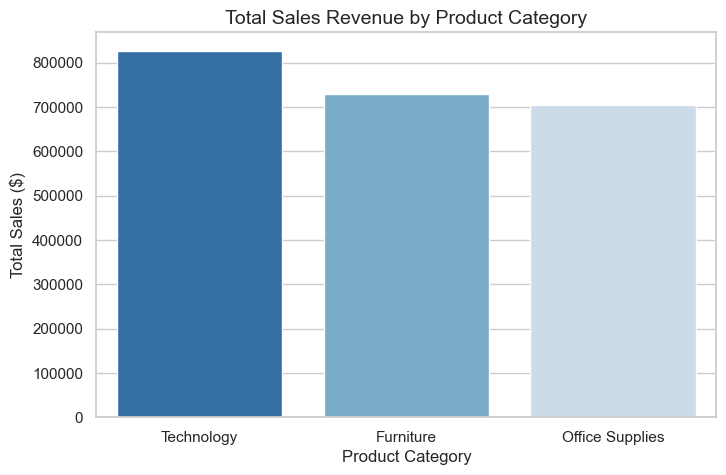

In [8]:
# Group data by Category and sum the sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

# Sort the values so the chart goes from highest to lowest
category_sales = category_sales.sort_values(by='Sales', ascending=False)

# Create the plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_r')

# Add labels and titles for clarity
plt.title('Total Sales Revenue by Product Category', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Format the y-axis to show standard numbers instead of scientific notation
plt.ticklabel_format(style='plain', axis='y')

plt.show()

## 4. Sales Trends Over Time (Seasonality & Growth)
To understand if the business is growing or if there are seasonal spikes (like holiday shopping), we need to look at sales over time. 

We will extract the Year and Month from our `Order Date` and plot a timeline of our revenue.

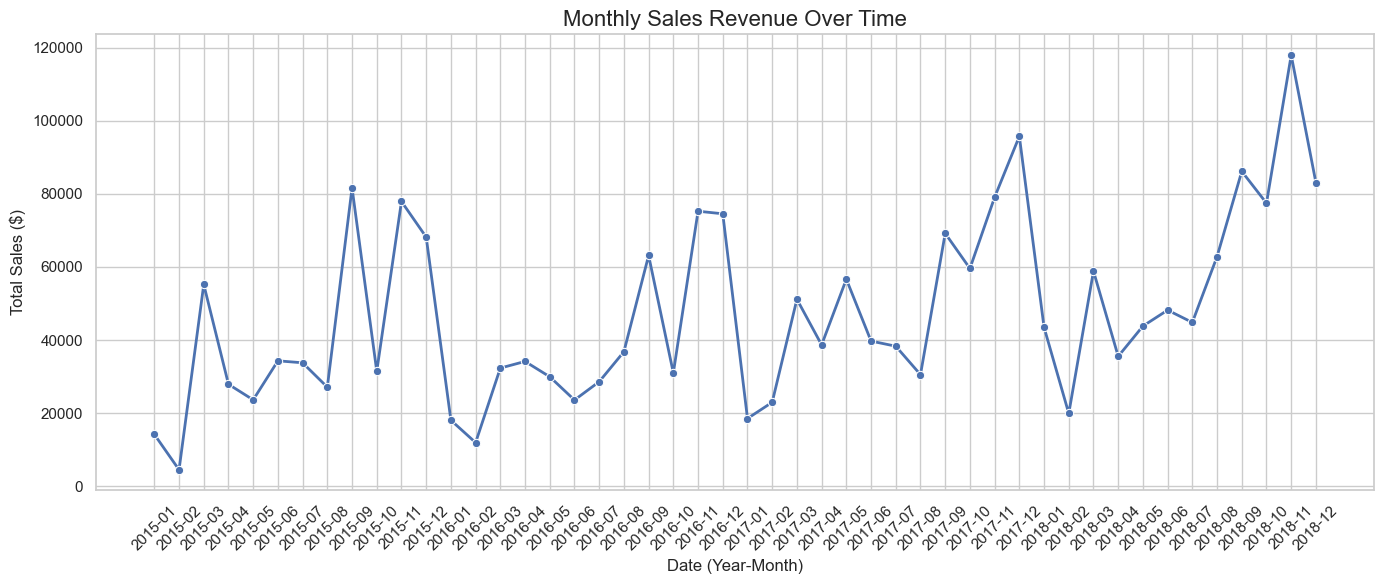

In [9]:
# Create a new column for Year-Month (e.g., '2017-01') for cleaner plotting
df['Year-Month'] = df['Order Date'].dt.strftime('%Y-%m')

# Group by this new column and calculate total sales per month
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()

# Sort chronologically
monthly_sales = monthly_sales.sort_values('Year-Month')

# Create the line plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Year-Month', y='Sales', marker='o', color='b', linewidth=2)

# Formatting the chart
plt.title('Monthly Sales Revenue Over Time', fontsize=16)
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout() # Ensures labels fit nicely

plt.show()

## 5. Customer Segments & Geographic Hotspots
Next, let's identify our core customer base. The dataset categorizes buyers into three segments: Consumer, Corporate, and Home Office. 

After looking at segments, we will identify the top 10 states driving the most revenue to see where our geographic strongholds are.

C:\Users\DELL\AppData\Local\Temp\ipykernel_13132\2235478138.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_sales, x='Segment', y='Sales', ax=axes[0], palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_13132\2235478138.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='Sales', y='State', ax=axes[1], palette='viridis')


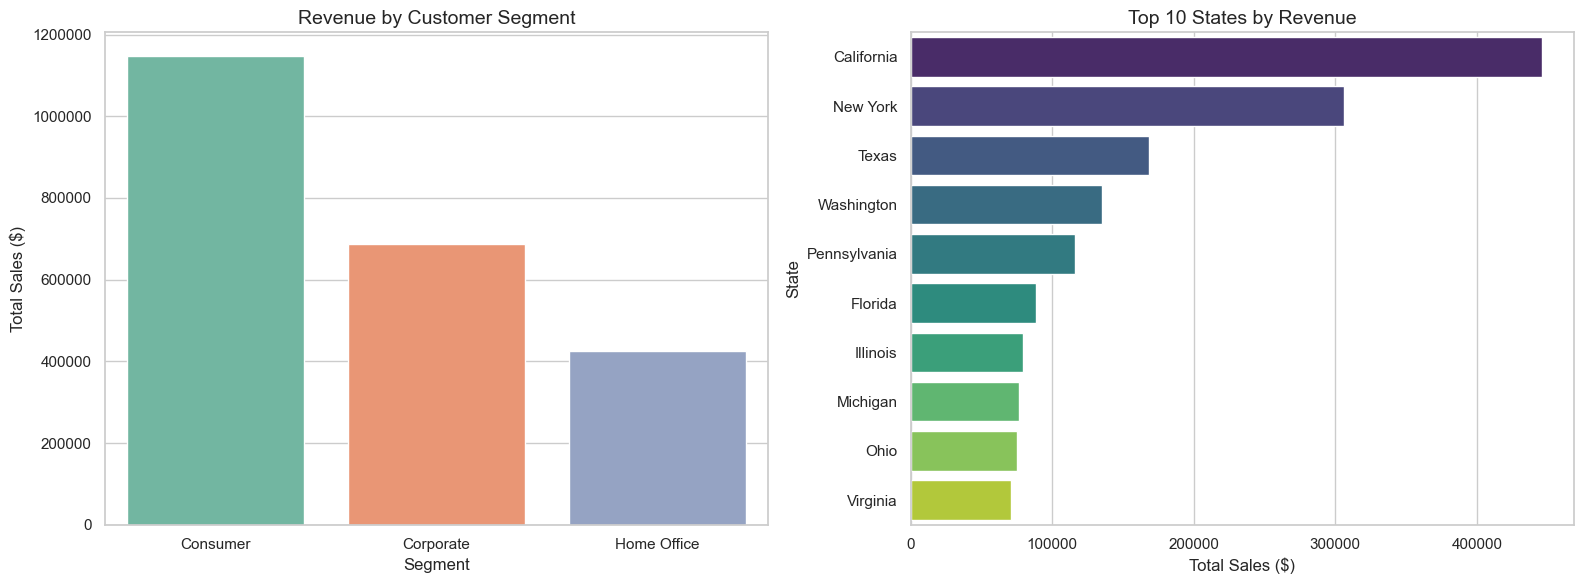

In [10]:
# --- 5A: Sales by Customer Segment ---
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# --- 5B: Top 10 States by Sales ---
state_sales = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart for Customer Segments
sns.barplot(data=segment_sales, x='Segment', y='Sales', ax=axes[0], palette='Set2')
axes[0].set_title('Revenue by Customer Segment', fontsize=14)
axes[0].set_ylabel('Total Sales ($)')
axes[0].ticklabel_format(style='plain', axis='y')

# Plot 2: Horizontal bar chart for Top 10 States
sns.barplot(data=state_sales, x='Sales', y='State', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 States by Revenue', fontsize=14)
axes[1].set_xlabel('Total Sales ($)')
axes[1].set_ylabel('State')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

## 6. Customer Behavioral Segmentation (RFM Analysis)
To truly understand our customer base, we will score every customer based on three metrics:
*   **Recency (R):** How many days has it been since their last purchase? (Lower is better).
*   **Frequency (F):** How many distinct orders have they placed? (Higher is better).
*   **Monetary (M):** How much money have they spent in total? (Higher is better).

We will assign a score from 1 to 4 for Recency and Frequency to categorize our customers into four distinct business groups:
1.  **Champions:** Bought recently and buy often. 
2.  **Potential Loyalists:** Bought recently, but haven't purchased many times yet.
3.  **At Risk:** Used to buy often, but haven't purchased in a long time.
4.  **Needs Attention:** Buy infrequently and haven't bought recently.

C:\Users\DELL\AppData\Local\Temp\ipykernel_13132\1847356287.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Customer Segment', y='Count', palette=colors)


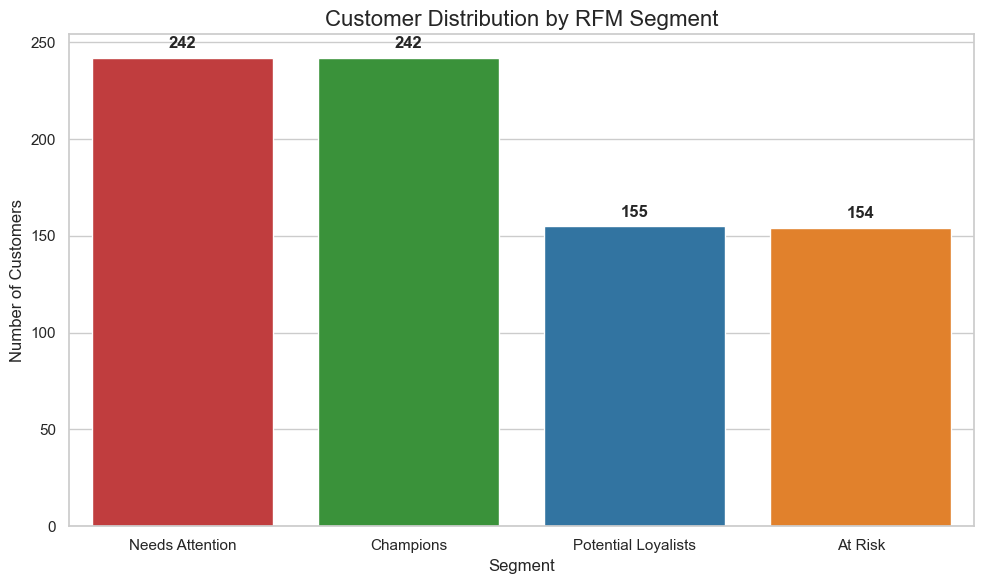

In [11]:
import datetime as dt

# --- 6A: Calculate R, F, and M for each customer ---
# Find the most recent date in the dataset to act as our "today"
reference_date = df['Order Date'].max() + dt.timedelta(days=1)

# Group by Customer ID to calculate the three metrics
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency: days since last order
    'Order ID': 'nunique',                                    # Frequency: count of unique orders
    'Sales': 'sum'                                            # Monetary: total spend
}).reset_index()

# Rename the columns so they are easy to read
rfm.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

# --- 6B: Score the Customers (1 to 4) ---
# We use quartiles to divide customers into 4 equal buckets.
# For Recency, a lower number of days is better, so the labels are reversed (4, 3, 2, 1).
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])

# For Frequency, higher is better. We use .rank() to prevent errors from customers with the exact same order count.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# --- 6C: Create the Business Segments ---
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r >= 3 and f >= 3:
        return 'Champions'
    elif r >= 3 and f < 3:
        return 'Potential Loyalists'
    elif r < 3 and f >= 3:
        return 'At Risk'
    else:
        return 'Needs Attention'

# Apply our rule to create the segment column
rfm['Customer Segment'] = rfm.apply(assign_segment, axis=1)

# --- 6D: Visualize the Results ---
# Count how many customers fall into each segment
segment_counts = rfm['Customer Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer Segment', 'Count']

plt.figure(figsize=(10, 6))
# We use a custom color palette to represent the "health" of the segment
colors = {'Champions': '#2ca02c', 'Potential Loyalists': '#1f77b4', 'At Risk': '#ff7f0e', 'Needs Attention': '#d62728'}

sns.barplot(data=segment_counts, x='Customer Segment', y='Count', palette=colors)

plt.title('Customer Distribution by RFM Segment', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add the actual numbers on top of the bars for clarity
for index, row in segment_counts.iterrows():
    plt.text(index, row['Count'] + 5, str(row['Count']), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()